In [86]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import joblib

import warnings
warnings.filterwarnings("ignore")

In [87]:
#Load data 1
df1 = pd.read_csv('C:/Users/mchar/Audible_Insights/data/Audible_Catlog.csv')

df1.head()

,Book Name,Author,Rating,Number of Reviews,Price
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0


In [88]:
df1.shape

(6368, 5)

In [89]:
df1.columns

Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='object')

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6368 entries, 0 to 6367
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          6368 non-null   object 
 1   Author             6368 non-null   object 
 2   Rating             6368 non-null   float64
 3   Number of Reviews  5737 non-null   float64
 4   Price              6365 non-null   float64
dtypes: float64(3), object(2)
memory usage: 248.9+ KB


In [90]:
df1.isnull().sum()

Book Name              0
Author                 0
Rating                 0
Number of Reviews    631
Price                  3
dtype: int64

In [91]:
df1.duplicated().sum()

np.int64(929)

In [92]:
#Load data 2
df2 = pd.read_csv('C:/Users/mchar/Audible_Insights/data/Audible_Catlog_Advanced_Features.csv')

df2.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [93]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          4464 non-null   object 
 1   Author             4464 non-null   object 
 2   Rating             4464 non-null   float64
 3   Number of Reviews  4043 non-null   float64
 4   Price              4464 non-null   int64  
 5   Description        4458 non-null   object 
 6   Listening Time     4464 non-null   object 
 7   Ranks and Genre    4464 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 279.1+ KB


In [94]:
df2.columns

Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='object')

In [95]:
df2.isnull().sum()

Book Name              0
Author                 0
Rating                 0
Number of Reviews    421
Price                  0
Description            6
Listening Time         0
Ranks and Genre        0
dtype: int64

In [96]:
df1.duplicated().sum()

np.int64(929)

In [97]:
print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)

Dataset 1: (6368, 5)
Dataset 2: (4464, 8)


In [98]:
#Clean columns Nmae
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
print(df1.columns.tolist())
print(df2.columns.tolist())

['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price']
['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price', 'Description', 'Listening Time', 'Ranks and Genre']


In [99]:
print("Dataset 1 Duplicates:", df1.duplicated().sum())
print("Dataset 2 Duplicates:", df2.duplicated().sum())

Dataset 1 Duplicates: 929
Dataset 2 Duplicates: 168


In [100]:
#Merge data 
merged_df = pd.merge(
    df1,
    df2,
    on=["Book Name", "Author"],
    how="left",
    suffixes=("_main", "_advanced")
)

print("Merged Dataset Shape:", merged_df.shape)

merged_df.head()

Merged Dataset Shape: (6819, 11)


,Book Name,Author,Rating_main,Number of Reviews_main,Price_main,Rating_advanced,Number of Reviews_advanced,Price_advanced,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,4.9,371.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,4.6,3682.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,4.4,20306.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,4.6,4678.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,4.6,4308.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [104]:
#Remove Advance columns
advanced_columns = [
    "Rating_advanced",
    "Number of Reviews_advanced",
    "Price_advanced"
]

merged_df = merged_df.drop(
    columns=advanced_columns,
    errors="ignore"
)
merged_df.head()

,Book Name,Author,Rating_main,Number of Reviews_main,Price_main,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [106]:
#make simple name
merged_df = merged_df.rename(columns={
    "Rating_main": "Rating",
    "Number of Reviews_main": "Number of Reviews",
    "Price_main": "Price"
})
merged_df.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [107]:
print(merged_df.columns.tolist())

['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price', 'Description', 'Listening Time', 'Ranks and Genre']


In [108]:
print(df1.columns.tolist())

['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price']


In [109]:
pd.set_option("display.max_colwidth", None)

merged_df[[
    "Book Name",
    "Ranks and Genre"
]].head(20)

,Book Name,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now,",#1 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Personal Success,#1 in Stress Management,#2 in Society & Culture (Books)"
1,Ikigai: The Japanese Secret to a Long and Happy Life,",#2 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Meditation (Audible Audiobooks & Originals),#1 in Self-Esteem,#2 in Personal Success"
2,The Subtle Art of Not Giving a F*ck: A Counterintuitive Approach to Living a Good Life,",#3 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#3 in Personal Success,#16 in Personal Development & Self-Help"
3,Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones,",#5 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Psychology (Audible Audiobooks & Originals),#3 in Stress Management,#4 in Personal Success"
4,Life's Amazing Secrets: How to Find Balance and Purpose in Your Life,",#6 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Literary Essays,#1 in Essays (Books),#1 in Spiritualism"
5,Extraordinary Leadership,",#1 Free in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Leadership,#1 in Business Careers"
6,Sapiens,",#4 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Anthropology (Audible Audiobooks & Originals),#1 in History of Civilization,#2 in Anthropology (Books)"
7,Sapiens,",#72 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#3 in Anthropology (Audible Audiobooks & Originals),#11 in Anthropology (Books)"
8,The Intelligent Investor Rev Ed.,",#7 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Personal Finance,#1 in Investing & Trading,#4 in Analysis & Strategy"
9,Rich Dad Poor Dad: What the Rich Teach Their Kids About Money - That the Poor and Middle Class Do Not!,",#9 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#2 in Personal Finance,#2 in Investing & Trading,#39 in Personal Development & Self-Help"


In [112]:
import re
def extract_rank_genre(text):
    if pd.isna(text):
        return pd.Series([pd.NA, pd.NA])

    # Find all "#number in category" entries
    matches = re.findall(
        r'#(\d+)\s+in\s+([^,#]+(?:\([^)]*\))?)',
        str(text)
    )

    # Prefer a meaningful category, not the generic Audible category
    for rank, genre in matches:
        genre = genre.strip()

        if "Audible Audiobooks & Originals" not in genre:
            return pd.Series([rank, genre])

    # If no other category exists, use the first available one
    if matches:
        rank, genre = matches[0]
        return pd.Series([rank, genre.strip()])

    return pd.Series([pd.NA, pd.NA])


merged_df[["Rank", "Genre"]] = merged_df[
    "Ranks and Genre"
].apply(extract_rank_genre)
merged_df[
    ["Book Name", "Ranks and Genre", "Rank", "Genre"]
].head(20)

,Book Name,Ranks and Genre,Rank,Genre
0,Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now,",#1 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Personal Success,#1 in Stress Management,#2 in Society & Culture (Books)",1,Personal Success
1,Ikigai: The Japanese Secret to a Long and Happy Life,",#2 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Meditation (Audible Audiobooks & Originals),#1 in Self-Esteem,#2 in Personal Success",1,Self-Esteem
2,The Subtle Art of Not Giving a F*ck: A Counterintuitive Approach to Living a Good Life,",#3 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#3 in Personal Success,#16 in Personal Development & Self-Help",3,Personal Success
3,Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones,",#5 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Psychology (Audible Audiobooks & Originals),#3 in Stress Management,#4 in Personal Success",3,Stress Management
4,Life's Amazing Secrets: How to Find Balance and Purpose in Your Life,",#6 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Literary Essays,#1 in Essays (Books),#1 in Spiritualism",1,Literary Essays
5,Extraordinary Leadership,",#1 Free in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Leadership,#1 in Business Careers",1,Leadership
6,Sapiens,",#4 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Anthropology (Audible Audiobooks & Originals),#1 in History of Civilization,#2 in Anthropology (Books)",1,History of Civilization
7,Sapiens,",#72 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#3 in Anthropology (Audible Audiobooks & Originals),#11 in Anthropology (Books)",11,Anthropology (Books)
8,The Intelligent Investor Rev Ed.,",#7 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#1 in Personal Finance,#1 in Investing & Trading,#4 in Analysis & Strategy",1,Personal Finance
9,Rich Dad Poor Dad: What the Rich Teach Their Kids About Money - That the Poor and Middle Class Do Not!,",#9 in Audible Audiobooks & Originals (See Top 100 in Audible Audiobooks & Originals),#2 in Personal Finance,#2 in Investing & Trading,#39 in Personal Development & Self-Help",2,Personal Finance


In [117]:
print(merged_df.columns.tolist())

['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price', 'Description', 'Listening Time', 'Rank', 'Genre']


In [118]:
# Check Missing Values

print("Missing Values:")
print(merged_df.isnull().sum())

Missing Values:
Book Name               0
Author                  0
Rating                  0
Number of Reviews     678
Price                   4
Description          2574
Listening Time       2568
Rank                 4808
Genre                4808
dtype: int64


In [119]:
# Handle Missing Values

# Reviews missing -> 0
merged_df["Number of Reviews"] = (
    merged_df["Number of Reviews"].fillna(0)
)

# Price missing -> Median Price
merged_df["Price"] = (
    merged_df["Price"].fillna(merged_df["Price"].median())
)

# Description missing -> empty text
# Better for NLP later
merged_df["Description"] = (
    merged_df["Description"].fillna("")
)

# Listening Time missing
merged_df["Listening Time"] = (
    merged_df["Listening Time"].fillna("Unknown")
)

# Rank missing
merged_df["Rank"] = (
    merged_df["Rank"].fillna("Unranked")
)

# Genre missing
merged_df["Genre"] = (
    merged_df["Genre"].fillna("Unknown")
)

In [120]:
print(merged_df.isnull().sum())

Book Name            0
Author               0
Rating               0
Number of Reviews    0
Price                0
Description          0
Listening Time       0
Rank                 0
Genre                0
dtype: int64


In [121]:
#Check dupblocate
duplicate_books = merged_df.duplicated(
    subset=["Book Name", "Author"]
).sum()

print("Duplicate Books:", duplicate_books)

Duplicate Books: 1416


In [123]:
#Remove Dubplicate
merged_df = merged_df.drop_duplicates(
    subset=["Book Name", "Author"],
    keep="first"
).reset_index(drop=True)

print("Duplicates after cleaning:",
      merged_df.duplicated(
          subset=["Book Name", "Author"]
      ).sum())

Duplicates after cleaning: 0


In [124]:
print("Final Dataset Shape:", merged_df.shape)

print("\nMissing Values:")
print(merged_df.isnull().sum())

print("\nColumns:")
print(merged_df.columns.tolist())

merged_df.head()

Final Dataset Shape: (5403, 9)

Missing Values:
Book Name            0
Author               0
Rating               0
Number of Reviews    0
Price                0
Description          0
Listening Time       0
Rank                 0
Genre                0
dtype: int64

Columns:
['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price', 'Description', 'Listening Time', 'Rank', 'Genre']


,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Rank,Genre
0,Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now,Jay Shetty,4.9,313.0,10080.0,"Over the past three years, Jay Shetty has become one of the world’s most popular influencers. One of his clips was the most watched video on Facebook last year, with more than 360 million views. His social media following totals more than 32 million, he has produced more than 400 viral videos which have amassed more than five billion views, and his podcast, On Purpose, is consistently ranked the world’s number one health-related podcast.",10 hours and 54 minutes,1,Personal Success
1,Ikigai: The Japanese Secret to a Long and Happy Life,Héctor García,4.6,3658.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,1,Self-Esteem
2,The Subtle Art of Not Giving a F*ck: A Counterintuitive Approach to Living a Good Life,Mark Manson,4.4,20174.0,10378.0,"In this generation-defining self-help guide, a superstar blogger cuts through the crap to show us how to stop trying to be positive all the time so that we can truly become better, happier people.",5 hours and 17 minutes,3,Personal Success
3,Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones,James Clear,4.6,4614.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,3,Stress Management
4,Life's Amazing Secrets: How to Find Balance and Purpose in Your Life,Gaur Gopal Das,4.6,4302.0,1005.0,"Stop going through life, Start growing through life!",6 hours and 25 minutes,1,Literary Essays


In [125]:
#Save
merged_df.to_csv(
    "../data/audible_cleaned.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [ ]:
#EDA Step 1

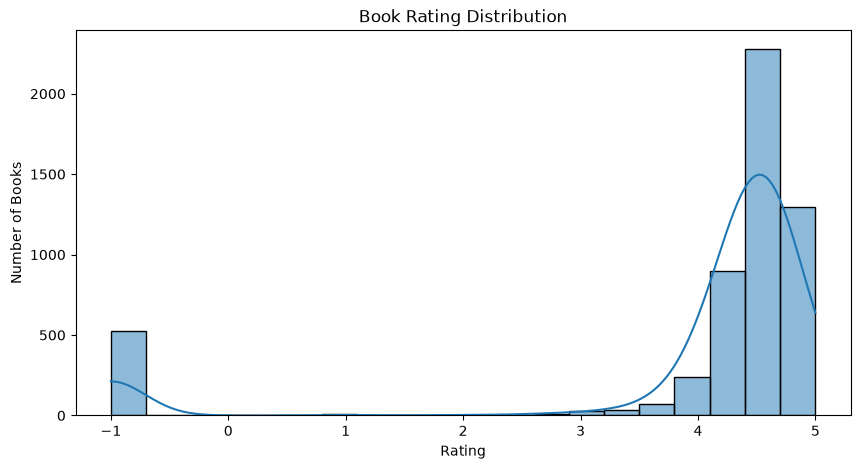

In [126]:
#1. Rating Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    merged_df["Rating"],
    bins=20,
    kde=True
)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

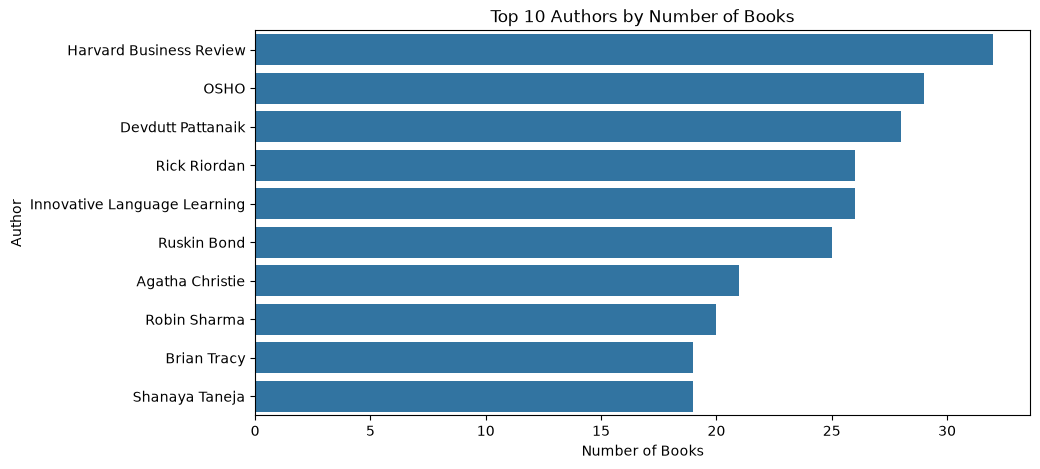

In [127]:
#2. Top 10 Authors by Number of Books
top_authors = merged_df["Author"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_authors.values,
    y=top_authors.index
)

plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")

plt.show()

In [128]:
#3. Average Rating by Author
author_stats = (
    merged_df.groupby("Author")
    .agg(
        Average_Rating=("Rating", "mean"),
        Book_Count=("Book Name", "count")
    )
)

top_author_ratings = (
    author_stats[author_stats["Book_Count"] >= 3]
    .sort_values("Average_Rating", ascending=False)
    .head(10)
)

top_author_ratings

,Average_Rating,Book_Count
Author,,
Tracey West,4.866667,3
Tui T. Sutherland,4.855556,9
Watchman Nee,4.800000,3
Joyce Meyer,4.800000,3
Anodea Judith,4.800000,3
Alan Watts,4.800000,5
Norman Bridwell,4.775000,4
John Flanagan,4.766667,3
Liz Pichon,4.750000,14


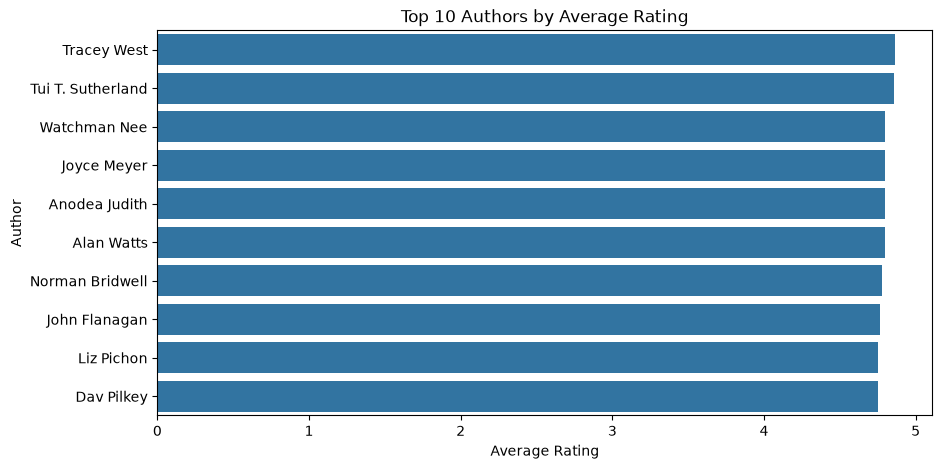

In [129]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_author_ratings["Average_Rating"],
    y=top_author_ratings.index
)

plt.title("Top 10 Authors by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Author")

plt.show()

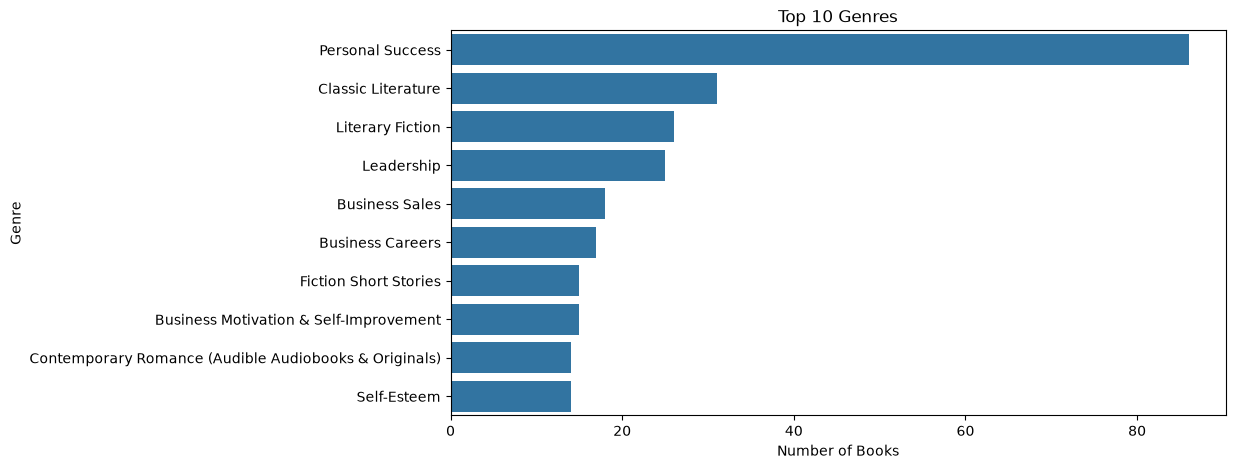

In [130]:
#Top Genres
genre_data = merged_df[
    merged_df["Genre"] != "Unknown"
]

top_genres = genre_data["Genre"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres")
plt.xlabel("Number of Books")
plt.ylabel("Genre")

plt.show()

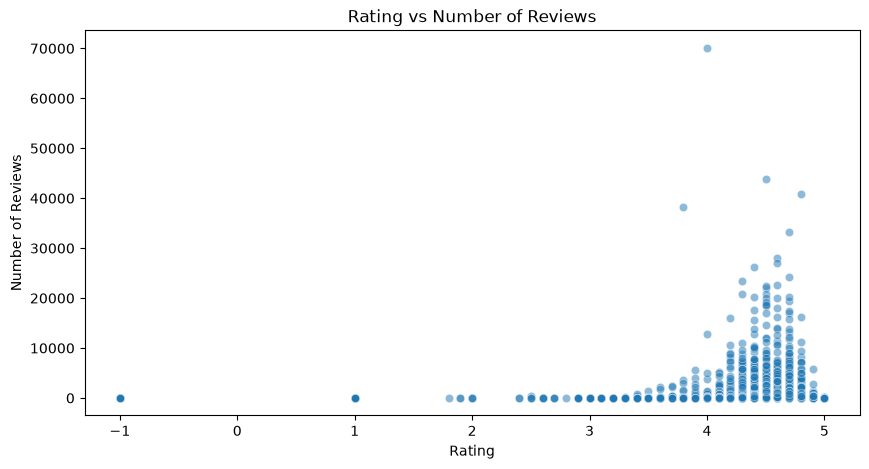

In [131]:
#Rating vs Number of Reviews
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=merged_df,
    x="Rating",
    y="Number of Reviews",
    alpha=0.5
)

plt.title("Rating vs Number of Reviews")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [132]:
#Top Rated Books
top_rated_books = (
    merged_df[merged_df["Number of Reviews"] >= 100]
    .sort_values(
        by=["Rating", "Number of Reviews"],
        ascending=[False, False]
    )
    [["Book Name", "Author", "Rating", "Number of Reviews"]]
    .head(10)
)

top_rated_books

,Book Name,Author,Rating,Number of Reviews
1965,Awaking Wonder: Opening Your Child's Heart to the Beauty of Learning,Sally Clarkson,5.0,209.0
181,F*cking History: 111 Lessons You Should Have Learned in School,The Captain,5.0,182.0
2546,High Achiever: The Incredible True Story of One Addict's Double Life,Tiffany Jenkins,4.9,5820.0
3957,"Relationship Goals: How to Win at Dating, Marriage, and Sex",Michael Todd,4.9,2864.0
1065,Inward,Yung Pueblo,4.9,1461.0
1470,"The Hive Queen: Wings of Fire, Book 12",Tui T. Sutherland,4.9,1420.0
1647,"Winter Turning: Wings of Fire, Book 7",Tui T. Sutherland,4.9,1203.0
4286,"Escaping Peril: Wings of Fire, Book 8",Tui T. Sutherland,4.9,1170.0
2627,"The Brightest Night: Wings of Fire, Book 5",Tui T. Sutherland,4.9,1120.0
4543,Darkstalker: Wings of Fire: Legends,Tui T. Sutherland,4.9,1024.0


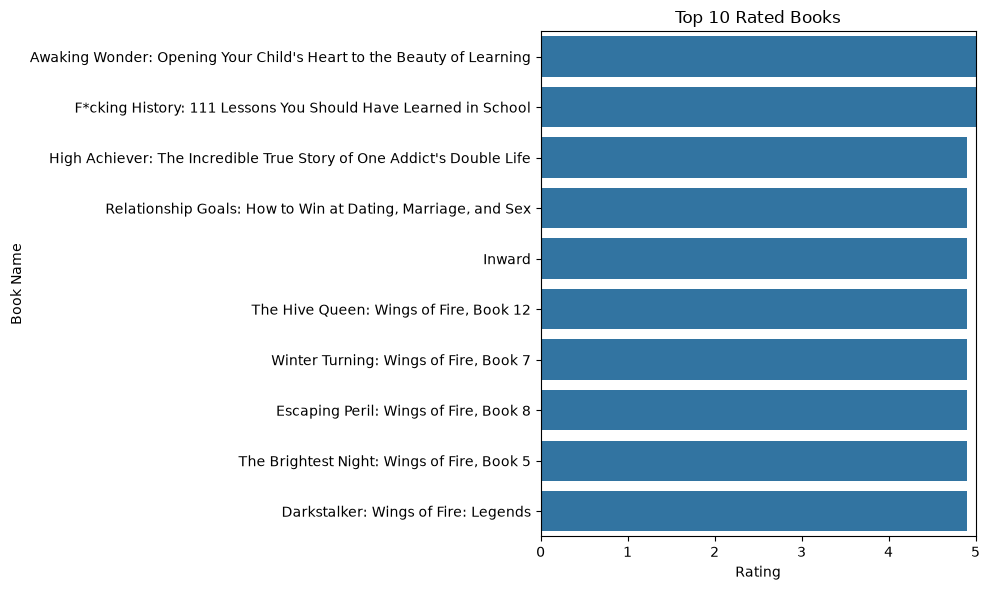

In [133]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_rated_books,
    x="Rating",
    y="Book Name"
)

plt.title("Top 10 Rated Books")
plt.xlabel("Rating")
plt.ylabel("Book Name")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [134]:
#Hidden Gems
high_rating = merged_df["Rating"].quantile(0.75)

positive_reviews = merged_df[
    merged_df["Number of Reviews"] > 0
]["Number of Reviews"]

low_reviews = positive_reviews.quantile(0.25)

hidden_gems = merged_df[
    (merged_df["Rating"] >= high_rating) &
    (merged_df["Number of Reviews"] > 0) &
    (merged_df["Number of Reviews"] <= low_reviews)
]

hidden_gems = (
    hidden_gems
    .sort_values(
        ["Rating", "Number of Reviews"],
        ascending=[False, False]
    )
    [["Book Name", "Author", "Rating", "Number of Reviews", "Genre"]]
    .head(10)
)

hidden_gems

,Book Name,Author,Rating,Number of Reviews,Genre
3232,"Raven’s Hart: Haven Hart Series, Book 7",Davidson King,5.0,37.0,Unknown
5190,The Fish Who Found the Sea,Alan Watts,5.0,30.0,Unknown
4229,Stop Making Sense: The Art of Inspiring Anybody,Michael J. Fanuele,5.0,28.0,Unknown
5332,The Book of Esports: The Definitive Guide to Competitive Video Games,William Collis,5.0,25.0,Unknown
3487,The Master Key System Audiobook - All 28 Parts,Charles F. Haanel,5.0,21.0,Unknown
1668,"Energy Healing for Trauma, Stress & Chronic Illness: Uncover & Transform the Subtle Energies that Are Causing Your Greatest Hardships",Cyndi Dale,5.0,16.0,Chakras
2576,Coming Home to Yourself: A Meditator's Guide to Blissful Living,Osho,5.0,16.0,Spirituality (Books)
4902,From a Mountain in Tibet: A Monk’s Journey,Lama Yeshe Losal Rinpoche,5.0,15.0,Unknown
4168,Discover Your True North: Expanded and Updated Edition,Bill George,5.0,14.0,Leadership
1636,Selling Technology the Sandler Way: Finding Technical Solutions That Win Long-Term Business Relationships,Rich Chiarello,5.0,12.0,Forecasting & Strategic Planning


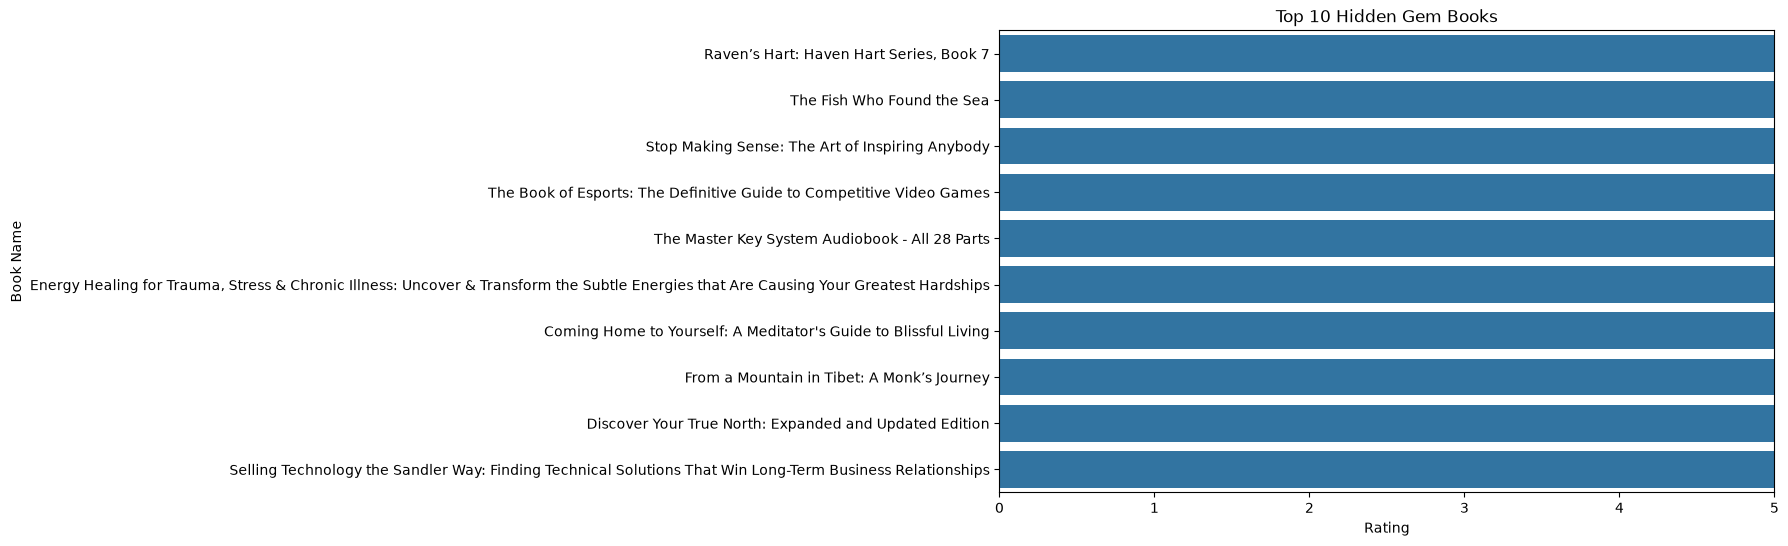

In [135]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=hidden_gems,
    x="Rating",
    y="Book Name"
)

plt.title("Top 10 Hidden Gem Books")
plt.xlabel("Rating")
plt.ylabel("Book Name")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [136]:
#Price Distribution
merged_df["Price"].describe()

count     5403.000000
mean       930.624653
std       1574.725873
min          0.000000
25%        501.000000
50%        680.000000
75%        888.000000
max      18290.000000
Name: Price, dtype: float64

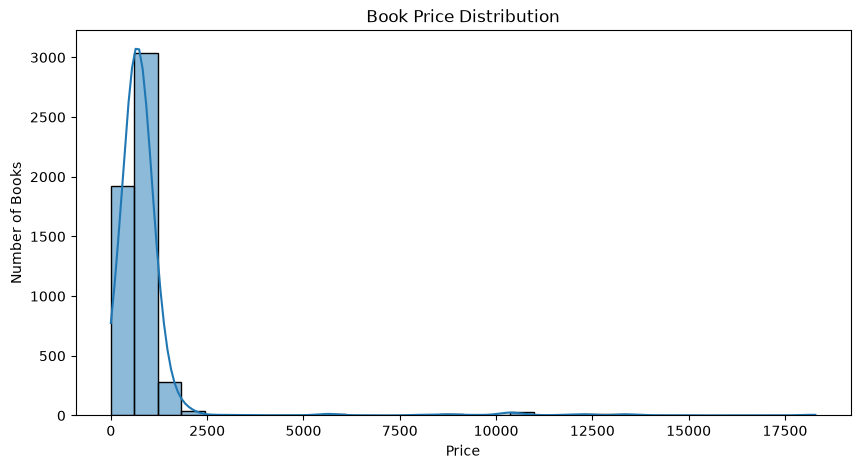

In [137]:
plt.figure(figsize=(10, 5))

sns.histplot(
    merged_df["Price"],
    bins=30,
    kde=True
)

plt.title("Book Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Books")

plt.show()

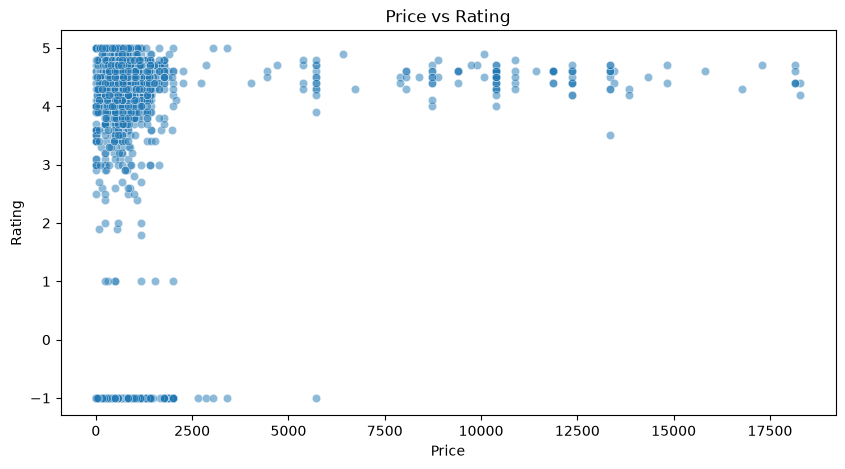

In [138]:
#Rating vs Price
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=merged_df,
    x="Price",
    y="Rating",
    alpha=0.5
)

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

In [ ]:
#EDA Summary
- Analyzed the distribution of book ratings.
- Identified the most represented authors and genres.
- Compared average ratings across authors.
- Examined the relationship between ratings and review counts.
- Identified highly rated books and potential hidden gems.
- Analyzed book prices and their relationship with ratings.

In [ ]:
#NLP

In [143]:
# Combine text with labels and separators

merged_df["combined_text"] = (
    "Book Name: " + merged_df["Book Name"].fillna("").astype(str) +
    " | Description: " + merged_df["Description"].fillna("").astype(str) +
    " | Genre: " + merged_df["Genre"].fillna("").astype(str)
)

merged_df[
    ["Book Name", "Description", "Genre", "combined_text"]
].head()

,Book Name,Description,Genre,combined_text
0,Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now,"Over the past three years, Jay Shetty has become one of the world’s most popular influencers. One of his clips was the most watched video on Facebook last year, with more than 360 million views. His social media following totals more than 32 million, he has produced more than 400 viral videos which have amassed more than five billion views, and his podcast, On Purpose, is consistently ranked the world’s number one health-related podcast.",Personal Success,"Book Name: Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now | Description: Over the past three years, Jay Shetty has become one of the world’s most popular influencers. One of his clips was the most watched video on Facebook last year, with more than 360 million views. His social media following totals more than 32 million, he has produced more than 400 viral videos which have amassed more than five billion views, and his podcast, On Purpose, is consistently ranked the world’s number one health-related podcast. | Genre: Personal Success"
1,Ikigai: The Japanese Secret to a Long and Happy Life,Brought to you by Penguin.,Self-Esteem,Book Name: Ikigai: The Japanese Secret to a Long and Happy Life | Description: Brought to you by Penguin. | Genre: Self-Esteem
2,The Subtle Art of Not Giving a F*ck: A Counterintuitive Approach to Living a Good Life,"In this generation-defining self-help guide, a superstar blogger cuts through the crap to show us how to stop trying to be positive all the time so that we can truly become better, happier people.",Personal Success,"Book Name: The Subtle Art of Not Giving a F*ck: A Counterintuitive Approach to Living a Good Life | Description: In this generation-defining self-help guide, a superstar blogger cuts through the crap to show us how to stop trying to be positive all the time so that we can truly become better, happier people. | Genre: Personal Success"
3,Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones,Brought to you by Penguin.,Stress Management,Book Name: Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones | Description: Brought to you by Penguin. | Genre: Stress Management
4,Life's Amazing Secrets: How to Find Balance and Purpose in Your Life,"Stop going through life, Start growing through life!",Literary Essays,"Book Name: Life's Amazing Secrets: How to Find Balance and Purpose in Your Life | Description: Stop going through life, Start growing through life! | Genre: Literary Essays"


In [147]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

merged_df["clean_text"] = merged_df["combined_text"].apply(clean_text)

merged_df[["Book Name", "clean_text"]].head()

,Book Name,clean_text
0,Think Like a Monk: The Secret of How to Harness the Power of Positivity and Be Happy Now,think like a monk the secret of how to harness the power of positivity and be happy now over the past three years jay shetty has become one of the world s most popular influencers one of his clips was the most watched video on facebook last year with more than 360 million views his social media following totals more than 32 million he has produced more than 400 viral videos which have amassed more than five billion views and his podcast on purpose is consistently ranked the world s number one health related podcast personal success
1,Ikigai: The Japanese Secret to a Long and Happy Life,ikigai the japanese secret to a long and happy life brought to you by penguin self esteem
2,The Subtle Art of Not Giving a F*ck: A Counterintuitive Approach to Living a Good Life,the subtle art of not giving a f ck a counterintuitive approach to living a good life in this generation defining self help guide a superstar blogger cuts through the crap to show us how to stop trying to be positive all the time so that we can truly become better happier people personal success
3,Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones,atomic habits an easy and proven way to build good habits and break bad ones brought to you by penguin stress management
4,Life's Amazing Secrets: How to Find Balance and Purpose in Your Life,life s amazing secrets how to find balance and purpose in your life stop going through life start growing through life literary essays


In [148]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(
    merged_df["clean_text"]
)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (5403, 5000)


In [149]:
#Book Index
book_indices = pd.Series(
    merged_df.index,
    index=merged_df["Book Name"]
)

book_indices = book_indices[
    ~book_indices.index.duplicated(keep="first")
]

print("Total Books Available:", len(book_indices))

Total Books Available: 5396


In [154]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_books(book_name, n=5):

    # Partial and case-insensitive book search
    matches = merged_df[
        merged_df["Book Name"].str.contains(
            book_name,
            case=False,
            na=False,
            regex=False
        )
    ]

    # If no book found
    if matches.empty:
        return "Book not found in dataset."

    # Select first matching book
    idx = matches.index[0]

    actual_book = merged_df.loc[idx, "Book Name"]

    # Calculate similarity
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    # Sort highest similarity first
    similar_indices = similarity_scores.argsort()[::-1]

    # Remove selected book itself
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ][:n]

    # Prepare recommendations
    result = merged_df.iloc[similar_indices][
        [
            "Book Name",
            "Author",
            "Genre",
            "Rating"
        ]
    ].copy()

    result["Similarity Score"] = similarity_scores[similar_indices]

    print("Selected Book:", actual_book)

    return result

In [157]:
recommend_books("Atomic Habits", 5)

Selected Book: Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones


,Book Name,Author,Genre,Rating,Similarity Score
885,High Performance Habits: How Extraordinary People Become That Way,Brendon Burchard,Stress Management,4.6,0.435881
3794,"Good Habits, Bad Habits: The Science of Making Positive Changes That Stick",Wendy Wood,Unknown,4.4,0.432782
157,Tiny Habits: The Small Changes That Change Everything,BJ Fogg,Personal Success,4.6,0.297615
2258,"Change Your Habits, Change Your Life: Strategies That Transformed 177 Average People into Self-Made Millionaires",Tom Corley,Money Management,4.4,0.296508
1983,"The Stress Solution: The 4 Steps to Reset Your Body, Mind, Relationships and Purpose",Dr Rangan Chatterjee,Stress Management,4.7,0.286863


In [158]:
recommend_books("Sapiens", 5)

Selected Book: Sapiens


,Book Name,Author,Genre,Rating,Similarity Score
3045,Energy and Civilization: A History,Vaclav Smil,Unknown,4.6,0.264994
5357,"Deadly Summer: Darling Investigations, Book 1",Denise Grover Swank,Unknown,4.6,0.217699
3986,The Great Reversal: How America Gave Up on Free Markets,Thomas Philippon,Unknown,4.7,0.215785
2557,"The Age of Napoleon: A History of European Civilization from 1789 to 1815: The Story of Civilization, Book 11",Will Durant,European History (Books),-1.0,0.200071
1205,Underworld: The Mysterious Origins of Civilization,Graham Hancock,History of Civilization & Culture,4.5,0.183287


In [159]:
#K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

merged_df["Cluster"] = kmeans.fit_predict(tfidf_matrix)

print("Clustering Completed")

Clustering Completed


In [160]:
print(merged_df["Cluster"].value_counts().sort_index())

Cluster
0    1567
1      66
2     751
3     156
4      85
5     284
6     100
7    1790
8     429
9     175
Name: count, dtype: int64


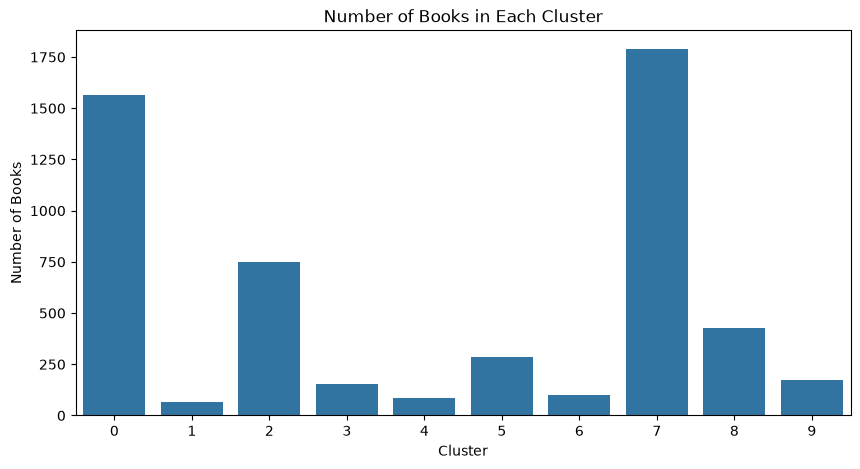

In [161]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=merged_df,
    x="Cluster"
)

plt.title("Number of Books in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Books")

plt.show()

In [162]:
#checked atomic habits
merged_df[
    merged_df["Book Name"].str.contains(
        "Atomic Habits",
        case=False,
        na=False,
        regex=False
    )
][["Book Name", "Genre", "Cluster"]]

,Book Name,Genre,Cluster
3,Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones,Stress Management,4


In [164]:
#Cluster-Based Recommendation Function
def cluster_recommendations(book_name, n=5):

    # Partial and case-insensitive search
    matches = merged_df[
        merged_df["Book Name"].str.contains(
            book_name,
            case=False,
            na=False,
            regex=False
        )
    ]

    if matches.empty:
        return "Book not found in dataset."

    # First matching book
    idx = matches.index[0]

    actual_book = merged_df.loc[idx, "Book Name"]

    # Find cluster
    cluster_id = merged_df.loc[idx, "Cluster"]

    # Books from same cluster
    recommendations = merged_df[
        (merged_df["Cluster"] == cluster_id) &
        (merged_df.index != idx)
    ].copy()

    # Sort by rating and reviews
    recommendations = recommendations.sort_values(
        by=["Rating", "Number of Reviews"],
        ascending=[False, False]
    )

    print("Selected Book:", actual_book)
    print("Cluster:", cluster_id)

    return recommendations[
        [
            "Book Name",
            "Author",
            "Genre",
            "Rating",
            "Number of Reviews",
            "Cluster"
        ]
    ].head(n)

In [165]:
cluster_recommendations("Atomic Habits", 5)

Selected Book: Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones
Cluster: 4


,Book Name,Author,Genre,Rating,Number of Reviews,Cluster
998,Life: A User’s Manual: Philosophy for Every and Any Eventuality,Julian Baggini,Philosophy of Society,5.0,2.0,4
5100,Terra Incognita: 100 Maps to Survive the Next 100 Years,Dr Ian Goldin,Climate Change,5.0,1.0,4
3479,Minecraft: The End,Catherynne M. Valente,Unknown,4.9,201.0,4
1014,Girl Decoded: My Quest to Make Technology Emotionally Intelligent - and Change the Way We Interact Forever,Rana el Kaliouby,Technology & Society,4.9,38.0,4
281,"The Body Keeps the Score: Mind, Brain and Body in the Transformation of Trauma",Bessel van der Kolk,PTSD,4.8,8191.0,4


In [ ]:
#combine TF-IDF + K-Means + Cosine Similarity

In [166]:
def hybrid_recommendations(book_name, n=5):

    matches = merged_df[
        merged_df["Book Name"].str.contains(
            book_name,
            case=False,
            na=False,
            regex=False
        )
    ]

    if matches.empty:
        return "Book not found in dataset."

    idx = matches.index[0]

    actual_book = merged_df.loc[idx, "Book Name"]
    cluster_id = merged_df.loc[idx, "Cluster"]

    # Similarity scores
    similarity_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    result = merged_df.copy()

    result["Similarity Score"] = similarity_scores

    # Keep books from same cluster
    result = result[
        (result["Cluster"] == cluster_id) &
        (result.index != idx)
    ].copy()

    # Normalize Rating to 0-1
    result["Rating Score"] = result["Rating"] / 5

    # Hybrid score
    result["Hybrid Score"] = (
        0.8 * result["Similarity Score"] +
        0.2 * result["Rating Score"]
    )

    result = result.sort_values(
        "Hybrid Score",
        ascending=False
    )

    print("Selected Book:", actual_book)
    print("Cluster:", cluster_id)

    return result[
        [
            "Book Name",
            "Author",
            "Genre",
            "Rating",
            "Similarity Score",
            "Hybrid Score"
        ]
    ].head(n)

In [167]:
hybrid_recommendations("Atomic Habits", 5)

Selected Book: Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones
Cluster: 4


,Book Name,Author,Genre,Rating,Similarity Score,Hybrid Score
157,Tiny Habits: The Small Changes That Change Everything,BJ Fogg,Personal Success,4.6,0.297615,0.422092
1983,"The Stress Solution: The 4 Steps to Reset Your Body, Mind, Relationships and Purpose",Dr Rangan Chatterjee,Stress Management,4.7,0.286863,0.417490
649,How to Change Your Mind,Michael Pollan,Pain Management,4.7,0.235823,0.376658
41,To Kill a Mockingbird,Harper Lee,Unknown,4.5,0.190795,0.332636
2596,The Twits,Roald Dahl,Fiction Classics for Children,4.8,0.171787,0.329429


In [168]:
#K-Means Silhouette Score
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    tfidf_matrix,
    merged_df["Cluster"]
)

print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.0732


In [169]:
#Top 5 recommendations
result = recommend_books("Atomic Habits", 5)

if isinstance(result, pd.DataFrame):
    avg_similarity = result["Similarity Score"].mean()

    print(
        "Average Similarity Score:",
        round(avg_similarity, 4)
    )

Selected Book: Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones
Average Similarity Score: 0.3499


In [170]:
recommend_books("Ikigai", 5)

Selected Book: Ikigai: The Japanese Secret to a Long and Happy Life


,Book Name,Author,Genre,Rating,Similarity Score
3970,The Little Book of Ikigai: The Essential Japanese Way to Finding Your Purpose in Life,Ken Mogi,Unknown,4.2,0.410118
3659,Revolution from Within: A Book of Self-Esteem,Gloria Steinem,Unknown,4.6,0.333534
1229,Happy: Why More or Less Everything Is Absolutely Fine,Derren Brown,Personal Success,4.4,0.302244
360,"The Book of Ichigo Ichie: The Art of Making the Most of Every Moment, the Japanese Way",Francesc Miralles,Sustainable & Green Living,4.6,0.299873
1311,Honoring the Self: The Pyschology of Confidence and Respect,Nathaniel Branden PhD,Self-Esteem,4.4,0.272483


In [171]:
hybrid_recommendations("Atomic Habits", 5)

Selected Book: Atomic Habits: An Easy and Proven Way to Build Good Habits and Break Bad Ones
Cluster: 4


,Book Name,Author,Genre,Rating,Similarity Score,Hybrid Score
157,Tiny Habits: The Small Changes That Change Everything,BJ Fogg,Personal Success,4.6,0.297615,0.422092
1983,"The Stress Solution: The 4 Steps to Reset Your Body, Mind, Relationships and Purpose",Dr Rangan Chatterjee,Stress Management,4.7,0.286863,0.417490
649,How to Change Your Mind,Michael Pollan,Pain Management,4.7,0.235823,0.376658
41,To Kill a Mockingbird,Harper Lee,Unknown,4.5,0.190795,0.332636
2596,The Twits,Roald Dahl,Fiction Classics for Children,4.8,0.171787,0.329429


In [ ]:
"""" Model Evaluation

The recommendation system was evaluated using:

- Cosine Similarity for content-based recommendations.
- Silhouette Score for evaluating K-Means clustering quality.
- Recommendation results were manually inspected for relevance.
- A hybrid approach combines content similarity, clustering, and book ratings.

Precision and Recall were not calculated because the dataset does not contain explicit user-book interaction or relevance labels.""""

In [172]:
#Final Dataset Save
merged_df.to_csv(
    "../data/audible_final.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [173]:
import os
import joblib

# Create models folder if needed
os.makedirs("../models", exist_ok=True)

# Save models
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(tfidf_matrix, "../models/tfidf_matrix.pkl")
joblib.dump(kmeans, "../models/kmeans_model.pkl")
merged_df.to_pickle("../models/books_data.pkl")

print("All files saved successfully!")
print(os.listdir("../models"))

All files saved successfully!
['books_data.pkl', 'kmeans_model.pkl', 'tfidf_matrix.pkl', 'tfidf_vectorizer.pkl']
